Business Challenge II test

In [ ]:
#importing necessary packages
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#importing models used
from xgboost import XGBClassifier
import xgboost as xgb
from sklearn.linear_model import LogisticRegression

#importing metrics and tools
from sklearn.model_selection         import train_test_split, cross_val_score, StratifiedKFold, KFold
from sklearn.metrics                 import (confusion_matrix, classification_report,
                                              roc_curve, auc, ConfusionMatrixDisplay,
                                              accuracy_score, f1_score,
                                              precision_score, recall_score,
                                              precision_recall_curve, average_precision_score)
from sklearn.preprocessing import StandardScaler


In [ ]:
#Reading the dataset
df_orig = pd.read_csv('/content/ML_Dataset.csv')

df = df_orig

df.head()

,City,Country,Latitude,Longitude,Elevation,Uhi_class,B01,B02,B03,B04,...,Swir1_nir,Swir2_nir,Building_density_100m,Red,Green,Blue,Nir08,Lwir11,Ndvi_landsat,Lst
0,"Santiago, Chile",Chile,-33.586980,-70.580508,675.616943,Low,1707.0,1442.0,1597.0,1652.0,...,1.084603,1.000401,0.0005,0.086770,0.078713,0.054293,0.154145,40.995054,0.279663,-232.137350
1,"Santiago, Chile",Chile,-33.592099,-70.579480,682.552063,Low,1478.0,1431.0,1618.0,1661.0,...,1.046414,0.916878,0.0002,0.109265,0.098787,0.074835,0.173258,41.268496,0.226504,-231.863344
2,"Santiago, Chile",Chile,-33.597419,-70.578366,683.376038,Medium,1803.0,1675.0,1794.0,1866.0,...,1.180459,1.161017,0.0001,0.098650,0.088118,0.069692,0.128597,44.375476,0.131784,-228.729034
3,"Santiago, Chile",Chile,-33.597109,-70.566661,696.966370,Low,2186.0,2236.0,2500.0,2554.0,...,0.996465,0.966014,0.0012,0.162807,0.111658,0.077475,0.205625,39.333897,0.116215,-233.780367
4,"Santiago, Chile",Chile,-33.597079,-70.566296,697.116333,Medium,2124.0,1894.0,2122.0,2232.0,...,1.191092,1.216954,0.0010,0.170480,0.134263,0.115315,0.232437,39.641518,0.153772,-233.472183


In [ ]:
df['City'].unique()

array(['Santiago, Chile', 'Rio de Janeiro, Brazil',
       'Freetown, Sierra Leone'], dtype=object)

In [ ]:
santiago_df = df[df['City'] == 'Santiago, Chile'].drop(columns=['City', 'Country'], errors='ignore')
rio_df      = df[df['City'] == 'Rio de Janeiro, Brazil'].drop(columns=['City', 'Country'], errors='ignore')
freetown_df = df[df['City'] == 'Freetown, Sierra Leone'].drop(columns=['City', 'Country'], errors='ignore')

In [ ]:
# Use santiago_df instead of the full df
conditions_uhi_class = [
    (santiago_df['Uhi_class'] == 'High'),
    (santiago_df['Uhi_class'] == 'Medium'),
    (santiago_df['Uhi_class'] == 'Low')
]

choices_uhi_class = [3, 2, 1]

# Now the lengths will match perfectly
santiago_df['Uhi_class_encoded'] = np.select(conditions_uhi_class, choices_uhi_class, default=0)

# Clean up
santiago_df = santiago_df.drop(['Uhi_class', 'Latitude', 'Longitude'], axis=1)

df.head()

,City,Country,Latitude,Longitude,Elevation,Uhi_class,B01,B02,B03,B04,...,Swir1_nir,Swir2_nir,Building_density_100m,Red,Green,Blue,Nir08,Lwir11,Ndvi_landsat,Lst
0,"Santiago, Chile",Chile,-33.586980,-70.580508,675.616943,Low,1707.0,1442.0,1597.0,1652.0,...,1.084603,1.000401,0.0005,0.086770,0.078713,0.054293,0.154145,40.995054,0.279663,-232.137350
1,"Santiago, Chile",Chile,-33.592099,-70.579480,682.552063,Low,1478.0,1431.0,1618.0,1661.0,...,1.046414,0.916878,0.0002,0.109265,0.098787,0.074835,0.173258,41.268496,0.226504,-231.863344
2,"Santiago, Chile",Chile,-33.597419,-70.578366,683.376038,Medium,1803.0,1675.0,1794.0,1866.0,...,1.180459,1.161017,0.0001,0.098650,0.088118,0.069692,0.128597,44.375476,0.131784,-228.729034
3,"Santiago, Chile",Chile,-33.597109,-70.566661,696.966370,Low,2186.0,2236.0,2500.0,2554.0,...,0.996465,0.966014,0.0012,0.162807,0.111658,0.077475,0.205625,39.333897,0.116215,-233.780367
4,"Santiago, Chile",Chile,-33.597079,-70.566296,697.116333,Medium,2124.0,1894.0,2122.0,2232.0,...,1.191092,1.216954,0.0010,0.170480,0.134263,0.115315,0.232437,39.641518,0.153772,-233.472183


In [ ]:
santiago_df = santiago_df.drop(['B01', 'B02', 'B03', 'B04', 'B05', 'B06', 'B07', 'B08',
       'B8a', 'B11', 'B12', 'Lst', 'Red', 'Green', 'Blue', 'Bsi'], axis=1)


In [ ]:
santiago_df.columns

Index(['Elevation', 'Ndvi_sentinel', 'Evi', 'Savi', 'Gndvi', 'Lai', 'Ndwi',
       'Mndwi', 'Ndmi', 'Ndbi', 'Isa', 'Bu', 'Ndisi', 'Ndbai', 'Dbsi', 'Lse',
       'Albedo', 'Swir1_nir', 'Swir2_nir', 'Building_density_100m', 'Nir08',
       'Lwir11', 'Ndvi_landsat', 'Uhi_class_encoded'],
      dtype='object')

In [ ]:
santiago_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 21662 entries, 0 to 21661
Data columns (total 24 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Elevation              21662 non-null  float64
 1   Ndvi_sentinel          21662 non-null  float64
 2   Evi                    21662 non-null  float64
 3   Savi                   21662 non-null  float64
 4   Gndvi                  21662 non-null  float64
 5   Lai                    21662 non-null  float64
 6   Ndwi                   21662 non-null  float64
 7   Mndwi                  21662 non-null  float64
 8   Ndmi                   21662 non-null  float64
 9   Ndbi                   21662 non-null  float64
 10  Isa                    21662 non-null  float64
 11  Bu                     21662 non-null  float64
 12  Ndisi                  21662 non-null  float64
 13  Ndbai                  21662 non-null  float64
 14  Dbsi                   21662 non-null  float64
 15  Lse    

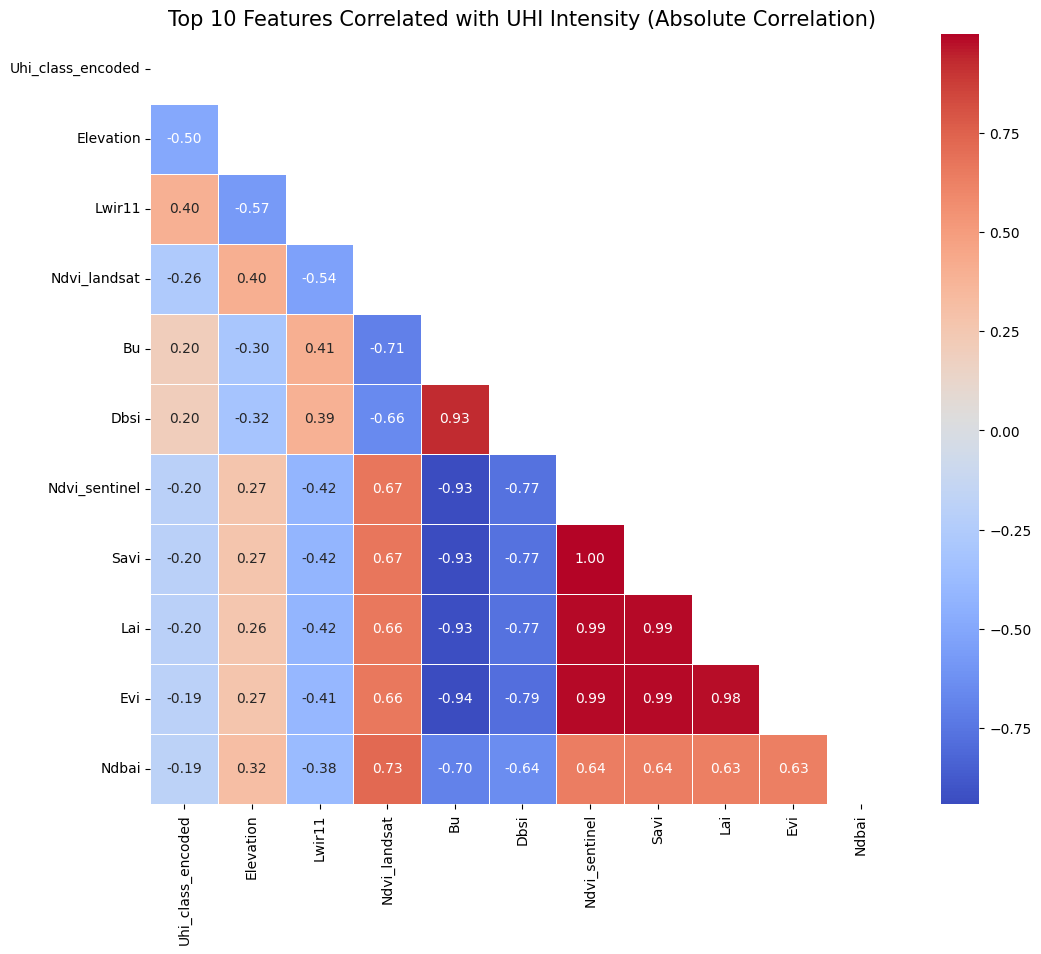

In [ ]:
# 1. Calculate correlations with 'Uhi_class_encoded'
# Using .abs() ensures we see features with strong negative correlations (like NDVI) too!
correlations = santiago_df.corr(numeric_only=True)['Uhi_class_encoded'].abs().sort_values(ascending=False)

# 2. Select the top 10 most correlated features (skipping the target itself at index 0)
top_10_features = correlations.index[1:11].tolist()

# 3. Add 'Uhi_class_encoded' back to the list for the heatmap
selected_features = ['Uhi_class_encoded'] + top_10_features

# 4. Create a DataFrame with only these features
santiago_df_top_10 = santiago_df[selected_features]

# 5. Calculate the correlation matrix
corr_matrix = santiago_df_top_10.corr(numeric_only=True)

# 6. Create a mask for the upper triangle (cleaner look)
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# 7. Plotting
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix,
            annot=True,
            cmap='coolwarm',
            fmt=".2f",
            mask=mask,
            linewidths=0.5)

plt.title('Top 10 Features Correlated with UHI Intensity (Absolute Correlation)', fontsize=15)
plt.show()

In [ ]:
x_selection = santiago_df.drop(columns=['Uhi_class_encoded'], axis=1)

y = santiago_df['Uhi_class_encoded']

In [ ]:
import numpy as np
from sklearn.preprocessing import StandardScaler

# 1. Replace Infinity with NaN
# This catches both positive and negative infinity
x_selection = x_selection.replace([np.inf, -np.inf], np.nan)

# 2. Handle NaNs (Fill with median)
# We use median because it's robust against the extreme outliers common in satellite data
x_selection = x_selection.fillna(x_selection.median())

# 3. Handle "Values too large" (Clipping)
# This caps extreme values at the 1st and 99th percentiles to prevent math overflow
x_selection = x_selection.clip(lower=x_selection.quantile(0.01), upper=x_selection.quantile(0.99), axis=1)

# 4. Scaling (MANDATORY for Logistic Regression)
# Without this, 'Elevation' will drown out all your spectral bands
scaler = StandardScaler()
x_selection_scaled = scaler.fit_transform(x_selection)

# Convert back to DataFrame to keep column names for the split
x_selection = pd.DataFrame(x_selection_scaled, columns=x_selection.columns)

print("✅ Data cleaned: Infinity removed, NaNs filled, and features scaled.")

✅ Data cleaned: Infinity removed, NaNs filled, and features scaled.


In [ ]:
# Split the cleaned data
X_train, X_test, y_train, y_test = train_test_split(
    x_selection, y, test_size=0.2, random_state=42, stratify=y
)

# Initialize and fit
lr = LogisticRegression(
    random_state=42,
    class_weight='balanced',
    solver='lbfgs',      # Better for multi-class 'multinomial' logic
    multi_class='auto',   # Automatically handles the 3+ levels
    #solver='liblinear',
    penalty="l2",
    C=0.1, # Increased slightly now that data is scaled
    max_iter=1000 # Increased to ensure convergence
)

lr.fit(X_train, y_train)

# Evaluation
y_pred_lr = lr.predict(X_test)
y_prob_lr  = lr.predict_proba(X_test)[:, 1]   # P(Default)

acc_lr = accuracy_score(y_test, y_pred_lr)
# Create names that match the NUMBER of unique values found in y_test
# Adjust these labels based on what the print(np.unique(y_test)) showed you
target_names = ["Low UHI (1)", "Medium UHI (2)", "High UHI (3)"]

print(classification_report(
    y_test,
    y_pred_lr,
    target_names=target_names
))

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


                precision    recall  f1-score   support

   Low UHI (1)       0.55      0.62      0.58      1106
Medium UHI (2)       0.61      0.39      0.47      2163
  High UHI (3)       0.41      0.66      0.51      1064

      accuracy                           0.51      4333
     macro avg       0.52      0.56      0.52      4333
  weighted avg       0.55      0.51      0.51      4333



In [ ]:
import pandas as pd
from sklearn.metrics import f1_score

# 1. Generate predictions for BOTH train and test sets
# (We need the train predictions to calculate the Gap)
y_pred_train_lr = lr.predict(X_train)
y_pred_test_lr  = lr.predict(X_test)

# 2. Calculate F1 Scores
# Since you have multiple UHI classes (1, 2, 3), we need to specify how to average them.
# 'weighted' accounts for class imbalance, which is standard for geospatial data.
f1_train_lr = f1_score(y_train, y_pred_train_lr, average='weighted')
f1_test_lr  = f1_score(y_test, y_pred_test_lr, average='weighted')

# 3. Calculate the overfitting Gap
gap_lr = f1_train_lr - f1_test_lr

# 4. Store the results in a list of dictionaries
# This makes it incredibly easy to append other models (RF, XGBoost, etc.) later
model_metrics = []

model_metrics.append({
    'Model': 'Logistic',
    'Type': 'Parametric',
    'F1_Train': f1_train_lr,
    'F1_Test': f1_test_lr,
    'Gap': gap_lr
})

# 5. Convert to a Pandas DataFrame
results_df = pd.DataFrame(model_metrics)

# 6. Format the floats to 4 decimal places to match your screenshot perfectly
results_df['F1_Train'] = results_df['F1_Train'].apply(lambda x: f"{x:.4f}")
results_df['F1_Test']  = results_df['F1_Test'].apply(lambda x: f"{x:.4f}")
results_df['Gap']      = results_df['Gap'].apply(lambda x: f"{x:.4f}")

# Display the clean table
results_df

,Model,Type,F1_Train,F1_Test,Gap
0,Logistic,Parametric,0.5137,0.5099,0.0038


Diving into our target label to understand each of the two population, it seems counter intuitive to see that the defaulted population has, as means, higher income for lower loans at lower interest rates.

In [ ]:
#display all numerical values grouped by loan_status
df_per_status = santiago_df.groupby('Uhi_class_encoded').mean()

#pivot the table
df_per_status = df_per_status.T

#plot
df_per_status.round(2).head(11)


Uhi_class_encoded,1,2,3
Elevation,680.41,568.41,521.72
Ndvi_sentinel,0.15,0.12,0.11
Evi,0.15,0.12,0.10
Savi,0.23,0.18,0.16
Gndvi,0.18,0.16,0.15
Lai,0.83,0.77,0.74
Ndwi,-0.18,-0.16,-0.15
Mndwi,-0.19,-0.20,-0.19
Ndmi,-0.01,-0.04,-0.04
Ndbi,0.01,0.04,0.04


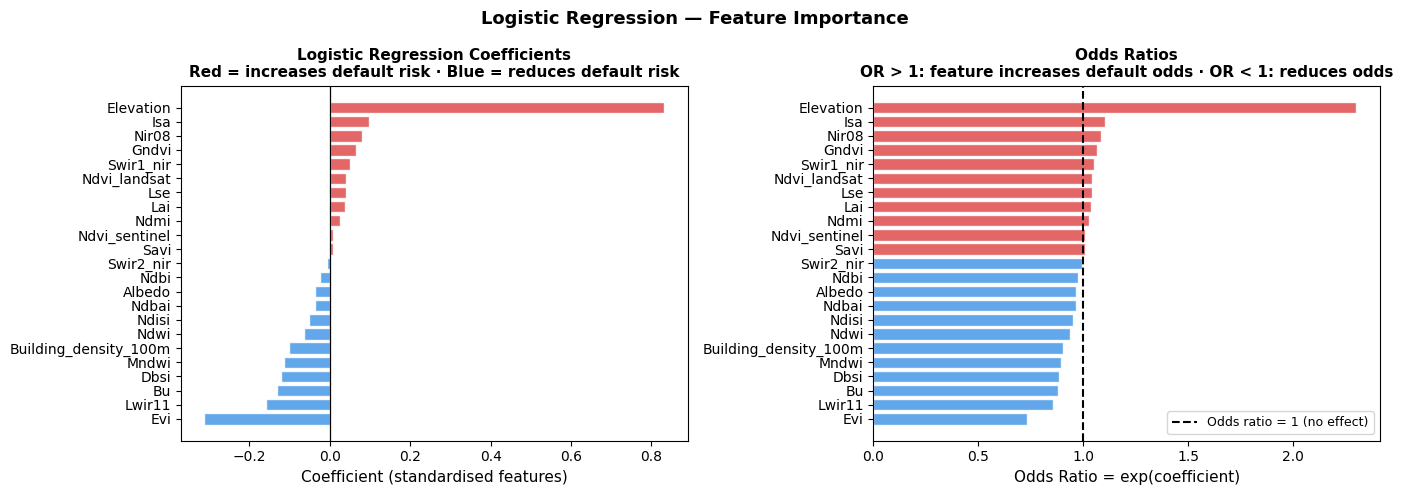

In [ ]:
# --- Coefficient plot + odds ratios ---
feature_names_used = X_train.columns   # columns actually used before scaling

coef_series = pd.Series(lr.coef_[0], index=feature_names_used).sort_values()
odds_ratios = np.exp(coef_series)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Coefficients
ax = axes[0]
bar_colors = ["#e05252" if c > 0 else "#4c9be8" for c in coef_series]
ax.barh(coef_series.index, coef_series.values, color=bar_colors, alpha=0.88, edgecolor="white")
ax.axvline(0, color="black", lw=0.9)
ax.set_xlabel("Coefficient (standardised features)", fontsize=11)
ax.set_title("Logistic Regression Coefficients\n"
             "Red = increases default risk · Blue = reduces default risk",
             fontsize=11, fontweight="bold")

# Odds ratios
ax = axes[1]
or_colors = ["#e05252" if o > 1 else "#4c9be8" for o in odds_ratios]
ax.barh(odds_ratios.index, odds_ratios.values, color=or_colors, alpha=0.88, edgecolor="white")
ax.axvline(1.0, color="black", lw=1.5, linestyle="--", label="Odds ratio = 1 (no effect)")
ax.set_xlabel("Odds Ratio = exp(coefficient)", fontsize=11)
ax.set_title("Odds Ratios\n"
             "OR > 1: feature increases default odds · OR < 1: reduces odds",
             fontsize=11, fontweight="bold")
ax.legend(fontsize=9)

plt.suptitle("Logistic Regression — Feature Importance", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

The predicted probability distribution that we can see below reflects how does the split between true good credit and true default is shared when we split through the mean at 0.5, naively. This will be clearly addressed further down this analysis.

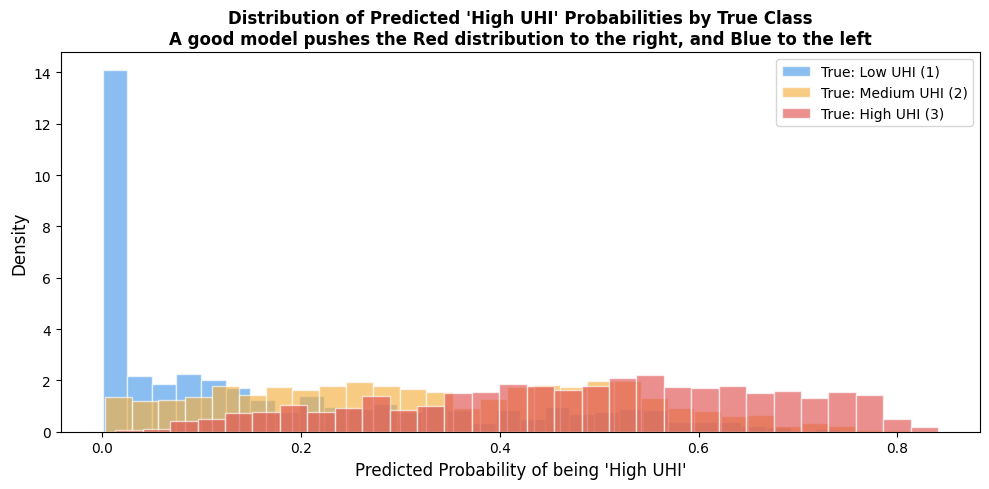

In [ ]:
import matplotlib.pyplot as plt

# 1. IMPORTANT: In multi-class, predict_proba returns a matrix of probabilities for ALL classes.
# We want to extract just the probability column for "High UHI".
# If your classes are [1, 2, 3], High UHI is the 3rd column (index 2).
# (If your classes are [0, 1, 2, 3], it would be index 3).
y_prob_all_classes = lr.predict_proba(X_test)
prob_high_uhi = y_prob_all_classes[:, 2]

# 2. Plotting
fig, ax = plt.subplots(figsize=(10, 5))

# Histogram for actual Low UHI (assuming encoded as 1)
ax.hist(prob_high_uhi[y_test == 1], bins=30, alpha=0.65, color="#4c9be8",
        label="True: Low UHI (1)", density=True, edgecolor="white")

# Histogram for actual Medium UHI (assuming encoded as 2)
ax.hist(prob_high_uhi[y_test == 2], bins=30, alpha=0.65, color="#f5b041",
        label="True: Medium UHI (2)", density=True, edgecolor="white")

# Histogram for actual High UHI (assuming encoded as 3)
ax.hist(prob_high_uhi[y_test == 3], bins=30, alpha=0.65, color="#e05252",
        label="True: High UHI (3)", density=True, edgecolor="white")

# Formatting
ax.set_xlabel("Predicted Probability of being 'High UHI'", fontsize=12)
ax.set_ylabel("Density", fontsize=12)
ax.set_title("Distribution of Predicted 'High UHI' Probabilities by True Class\n"
             "A good model pushes the Red distribution to the right, and Blue to the left",
             fontsize=12, fontweight="bold")
ax.legend(fontsize=10)

plt.tight_layout()
plt.show()

In [ ]:
# XGBoost Classifier
xgb = XGBClassifier(n_estimators=100, #estimators number chosen alongside learning rate level to match the sequential learning basis of the model
                    learning_rate=0.1, #slow learning rate to avoid missing good steps towards the right direction
                    max_depth=10, #this works in locality to avoid local overfitting rather the the overall global noise
                    min_child_weight=20, #higher for imbalanced data to avoid overfitting, limiting the split when uncertain
                    random_state=42)


# 1. Shift the labels down by 1 so they become 0, 1, 2
y_train_xgb = y_train - 1
y_test_xgb  = y_test - 1

# 2. Train the model on the newly shifted targets
xgb.fit(X_train, y_train_xgb)

name = "XGBoost"

# 3. Make sure to use the shifted targets when calculating your F1 and Gap metrics later!
y_pred_train_xgb = xgb.predict(X_train)
y_pred_test_xgb  = xgb.predict(X_test)

# (Calculate metrics using y_train_xgb and y_test_xgb)

print(f"\n{'='*40}")
print(f" EVALUATING MODEL: {name}")
print(f"{'='*40}")

# 1. Generate predictions on the test set
y_pred_xgb = xgb.predict(X_test)
y_prob_xgb  = xgb.predict_proba(X_test)[:, 1]

acc_xgb = accuracy_score(y_test, y_pred_xgb)

target_names = ["Low UHI (1)", "Medium UHI (2)", "High UHI (3)"]

print(classification_report(
    y_test,
    y_pred_lr,
    target_names=target_names
))


 EVALUATING MODEL: XGBoost
                precision    recall  f1-score   support

   Low UHI (1)       0.55      0.62      0.58      1106
Medium UHI (2)       0.61      0.39      0.47      2163
  High UHI (3)       0.41      0.66      0.51      1064

      accuracy                           0.51      4333
     macro avg       0.52      0.56      0.52      4333
  weighted avg       0.55      0.51      0.51      4333



In [ ]:
import pandas as pd
from sklearn.metrics import f1_score

# ==========================================
# Initialize the list to store all model results
# ==========================================
model_metrics = []

# ==========================================
# 1. LOGISTIC REGRESSION (Parametric)
# ==========================================
# (Assuming y_pred_train_lr and y_pred_test_lr are already loaded in memory)
f1_train_lr = f1_score(y_train, y_pred_train_lr, average='weighted')
f1_test_lr  = f1_score(y_test, y_pred_test_lr, average='weighted')

model_metrics.append({
    'Model': 'Logistic',
    'Type': 'Parametric',
    'F1_Train': f1_train_lr,
    'F1_Test': f1_test_lr,
    'Gap': f1_train_lr - f1_test_lr
})

# ==========================================
# 2. XGBOOST (Non-parametric)
# ==========================================
# Calculate metrics using the zero-indexed targets and predictions
f1_train_xgb = f1_score(y_train_xgb, y_pred_train_xgb, average='weighted')
f1_test_xgb  = f1_score(y_test_xgb, y_pred_test_xgb, average='weighted')

model_metrics.append({
    'Model': 'XGBoost',
    'Type': 'Non-parametric',
    'F1_Train': f1_train_xgb,
    'F1_Test': f1_test_xgb,
    'Gap': f1_train_xgb - f1_test_xgb
})

# ==========================================
# 3. BUILD AND FORMAT THE TABLE
# ==========================================
results_df = pd.DataFrame(model_metrics)

# Format the floats to 4 decimal places for the numeric columns only
for col in ['F1_Train', 'F1_Test', 'Gap']:
    results_df[col] = results_df[col].apply(lambda x: f"{x:.4f}")

# Display the clean table
results_df

,Model,Type,F1_Train,F1_Test,Gap
0,Logistic,Parametric,0.5137,0.5099,0.0038
1,XGBoost,Non-parametric,0.8353,0.6948,0.1406


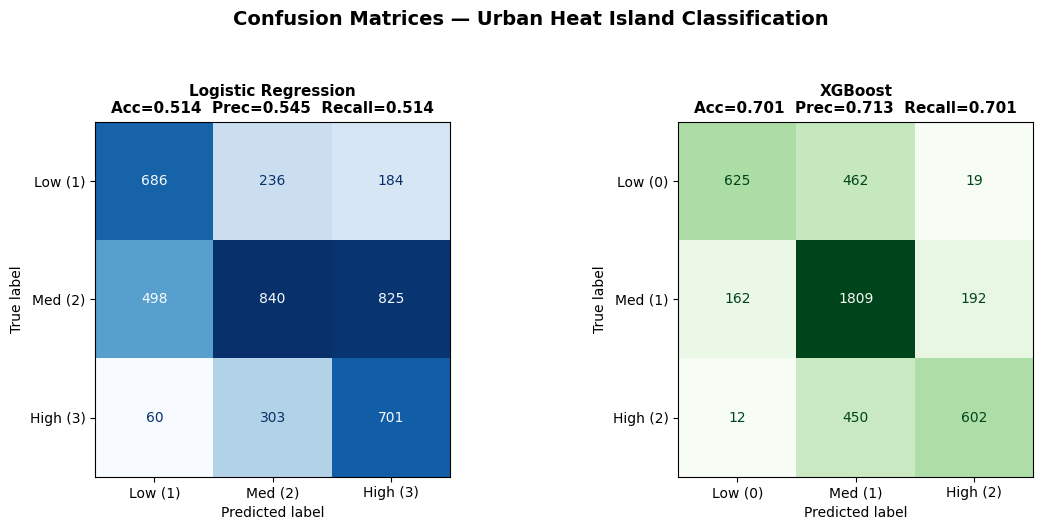

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import accuracy_score, precision_score, recall_score

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# We store: (Model Name, True Targets, Predictions, Color, Labels)
models_eval = [
    ("Logistic Regression", y_test,     y_pred_lr,  "Blues",  ["Low (1)", "Med (2)", "High (3)"]),
    ("XGBoost",             y_test_xgb, y_pred_xgb, "Greens", ["Low (0)", "Med (1)", "High (2)"])
]

for ax, (name, y_true, y_pred, cmap, labels) in zip(axes, models_eval):
    # 1. Generate the Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)

    # 2. Plot it
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
    disp.plot(ax=ax, colorbar=False, cmap=cmap)

    # 3. Calculate Multi-Class Metrics (Using 'weighted' average)
    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average='weighted', zero_division=0)
    rec  = recall_score(y_true, y_pred, average='weighted', zero_division=0)

    # 4. Set the title
    ax.set_title(f"{name}\nAcc={acc:.3f}  Prec={prec:.3f}  Recall={rec:.3f}",
                 fontsize=11, fontweight="bold")

plt.suptitle("Confusion Matrices — Urban Heat Island Classification",
             fontsize=14, fontweight="bold", y=1.05)
plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score)

# 1. Get the FULL probability matrices (required for Multi-class AUC-ROC)
# In multi-class, predict_proba returns a probability for every single class, not just one.
y_prob_lr_full  = lr.predict_proba(X_test)
y_prob_xgb_full = xgb.predict_proba(X_test)

rows = []

# 2. Loop through the models.
# CRITICAL: We pass the specific y_test arrays since XGBoost uses the shifted (0,1,2) labels!
for name, y_true, y_pred, y_prob in [
    ("Logistic Regression", y_test,     y_pred_lr,  y_prob_lr_full),
    ("XGBoost",             y_test_xgb, y_pred_xgb, y_prob_xgb_full)
]:
    # Calculate total wrong predictions instead of binary FP/FN
    misclassified = (y_true != y_pred).sum()

    rows.append({
        "Model"               : name,
        "Accuracy"            : f"{accuracy_score(y_true, y_pred):.4f}",
        "Precision (Weighted)": f"{precision_score(y_true, y_pred, average='weighted', zero_division=0):.4f}",
        "Recall (Weighted)"   : f"{recall_score(y_true, y_pred, average='weighted', zero_division=0):.4f}",
        "F1 (Weighted)"       : f"{f1_score(y_true, y_pred, average='weighted', zero_division=0):.4f}",
        "AUC-ROC (OVR)"       : f"{roc_auc_score(y_true, y_prob, multi_class='ovr', average='weighted'):.4f}",
        "Misclassified"       : misclassified
    })

# 3. Build and display the table
results_df = pd.DataFrame(rows).set_index("Model")
print(results_df.to_string())

                    Accuracy Precision (Weighted) Recall (Weighted) F1 (Weighted) AUC-ROC (OVR)  Misclassified
Model                                                                                                         
Logistic Regression   0.5140               0.5455            0.5140        0.5099        0.7128           2106
XGBoost               0.7007               0.7134            0.7007        0.6948        0.8329           1297


In order to fine tune the model, we must choose the best possible threshold to either maximize the F1 score and ability of the model to describe the data or minimize the cost which will be set to penalize five times more the false negatives than the false positives.

It is possible to observe that cost optimization is the best way to reduce the calculated penality cost of the model and increase its accuracy and precision. The amount of false negatives dropped, after tuning, from 151 to 22 only. It is a clear improvement.

In [ ]:
import numpy as np
from sklearn.metrics import confusion_matrix, f1_score, precision_score, recall_score

# 1. Isolate the "High UHI" Probabilities and Targets
# Remember: predict_proba returns a matrix. We want the 3rd column (index 2) for High UHI.
# (Make sure you are using y_prob_lr_full from the previous step)
prob_high_uhi = y_prob_lr_full[:, 2]

# Binarize your test set: 1 if it is High UHI (class 3), 0 if it is Low/Medium
y_test_binary = (y_test == 3).astype(int)

# 2. Define your business costs
FN_COST, FP_COST = 5, 1

# 3. Setup the sweep
thresholds = np.linspace(0.01, 0.99, 250)
f1s, precs, recs, costs, total_wrong = [], [], [], [], []

for t in thresholds:
    # Predict 1 (High UHI) if the probability is above our current threshold 't'
    yp = (prob_high_uhi >= t).astype(int)

    # Edge case handling: If the threshold is so extreme it predicts all 0s or all 1s
    if yp.sum() == 0 or yp.sum() == len(yp):
        f1s.append(0); precs.append(0); recs.append(0)
        costs.append(np.nan); total_wrong.append(np.nan)
        continue

    # Because we binarized the targets, this will perfectly output 4 values again!
    cm = confusion_matrix(y_test_binary, yp)
    tn, fp, fn, tp = cm.ravel()

    f1s.append(f1_score(y_test_binary, yp, zero_division=0))
    precs.append(precision_score(y_test_binary, yp, zero_division=0))
    recs.append(recall_score(y_test_binary, yp, zero_division=0))

    # Calculate custom business cost
    costs.append(fp * FP_COST + fn * FN_COST)
    total_wrong.append(fp + fn)

# 4. Find the optimal thresholds
best_f1_thresh   = thresholds[np.argmax(f1s)]
best_cost_thresh = thresholds[np.nanargmin(costs)]

print(f"Optimal Threshold to maximize F1 Score : {best_f1_thresh:.3f}")
print(f"Optimal Threshold to minimize UHI Cost : {best_cost_thresh:.3f}")

Optimal Threshold to maximize F1 Score : 0.348
Optimal Threshold to minimize UHI Cost : 0.250


In [ ]:
print(f"Default threshold (0.50):")
# Use the isolated High UHI probabilities
yp05 = (prob_high_uhi >= 0.50).astype(int)
# Grade against the binarized test set
cm05 = confusion_matrix(y_test_binary, yp05).ravel()
print(f"  TN={cm05[0]} FP={cm05[1]} FN={cm05[2]} TP={cm05[3]}")
print(f"  Total cost = {cm05[1]*FP_COST + cm05[2]*FN_COST}")
print()

print(f"F1-optimal threshold ({best_f1_thresh:.3f}):")
yp_f1 = (prob_high_uhi >= best_f1_thresh).astype(int)
cm_f1 = confusion_matrix(y_test_binary, yp_f1).ravel()
print(f"  TN={cm_f1[0]} FP={cm_f1[1]} FN={cm_f1[2]} TP={cm_f1[3]}")
print(f"  Total cost = {cm_f1[1]*FP_COST + cm_f1[2]*FN_COST}")
print()

print(f"Cost-optimal threshold ({best_cost_thresh:.3f}):")
yp_co = (prob_high_uhi >= best_cost_thresh).astype(int)
cm_co = confusion_matrix(y_test_binary, yp_co).ravel()
print(f"  TN={cm_co[0]} FP={cm_co[1]} FN={cm_co[2]} TP={cm_co[3]}")
print(f"  Total cost = {cm_co[1]*FP_COST + cm_co[2]*FN_COST}  ← minimum")

Default threshold (0.50):
  TN=2682 FP=587 FN=535 TP=529
  Total cost = 3262

F1-optimal threshold (0.348):
  TN=2056 FP=1213 FN=257 TP=807
  Total cost = 2498

Cost-optimal threshold (0.250):
  TN=1582 FP=1687 FN=141 TP=923
  Total cost = 2392  ← minimum


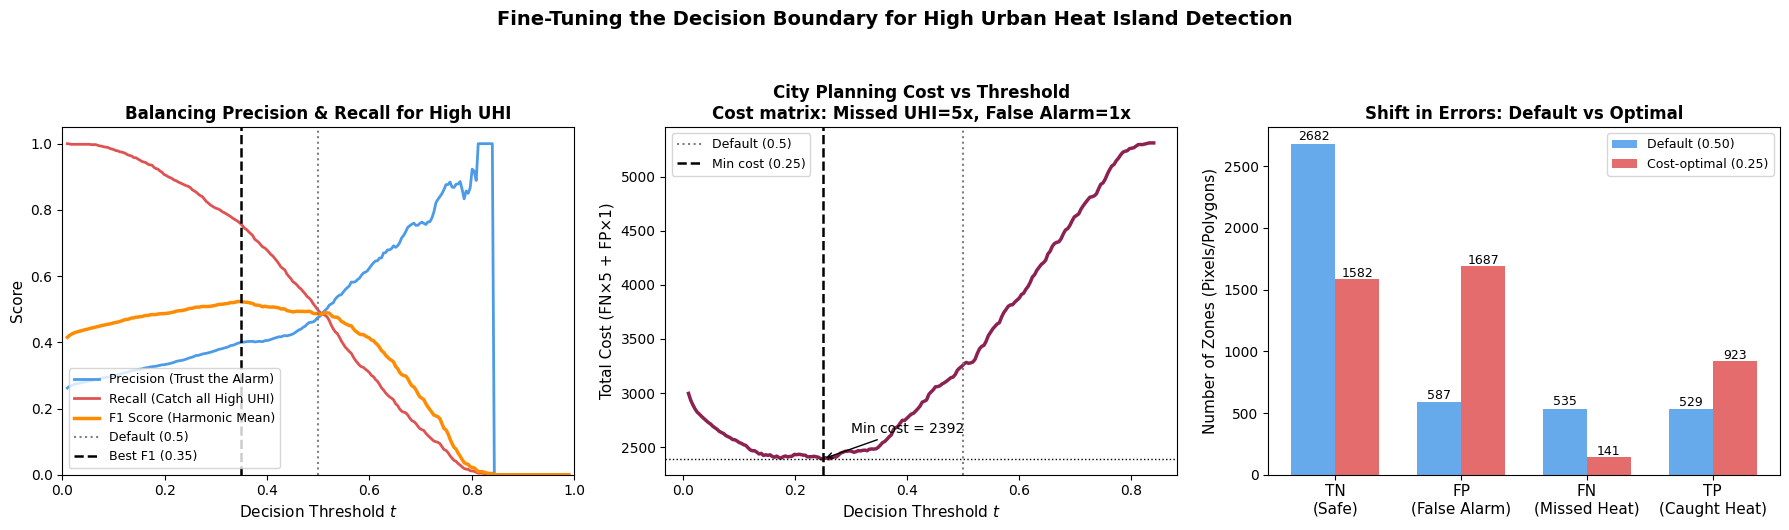

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ---------------------------------------------------------
# 1. Precision / Recall / F1 vs Threshold
# ---------------------------------------------------------
ax = axes[0]
ax.plot(thresholds, precs, lw=2, color="#4c9be8",  label="Precision (Trust the Alarm)")
ax.plot(thresholds, recs,  lw=2, color="#e05252",  label="Recall (Catch all High UHI)")
ax.plot(thresholds, f1s,   lw=2.5, color="darkorange", label="F1 Score (Harmonic Mean)")

ax.axvline(0.5, color="gray", linestyle=":", lw=1.5, label="Default (0.5)")
ax.axvline(best_f1_thresh, color="black", linestyle="--", lw=1.8, label=f"Best F1 ({best_f1_thresh:.2f})")

ax.set_xlabel("Decision Threshold $t$", fontsize=11)
ax.set_ylabel("Score", fontsize=11)
ax.set_title("Balancing Precision & Recall for High UHI", fontsize=12, fontweight="bold")
ax.legend(fontsize=9, loc="lower left")
ax.set_xlim(0, 1); ax.set_ylim(0, 1.05)


# ---------------------------------------------------------
# 2. Expected Cost vs Threshold
# ---------------------------------------------------------
ax = axes[1]
ax.plot(thresholds, costs, lw=2.5, color="#8b2252")

ax.axvline(0.5, color="gray", linestyle=":", lw=1.5, label="Default (0.5)")
ax.axvline(best_cost_thresh, color="black", linestyle="--", lw=1.8, label=f"Min cost ({best_cost_thresh:.2f})")

min_cost = np.nanmin(costs)
ax.axhline(min_cost, color="black", linestyle=":", lw=1)

# Adjusted annotation to prevent text from clipping off the chart
ax.annotate(f"Min cost = {int(min_cost)}",
            xy=(best_cost_thresh, min_cost),
            xytext=(best_cost_thresh + 0.05, min_cost + (min_cost * 0.1)),
            arrowprops=dict(arrowstyle="->", color="black"), fontsize=10)

ax.set_xlabel("Decision Threshold $t$", fontsize=11)
ax.set_ylabel(f"Total Cost (FN×{FN_COST} + FP×{FP_COST})", fontsize=11)
ax.set_title(f"City Planning Cost vs Threshold\nCost matrix: Missed UHI={FN_COST}x, False Alarm={FP_COST}x",
             fontsize=12, fontweight="bold")
ax.legend(fontsize=9)


# ---------------------------------------------------------
# 3. Confusion Matrices: Default vs Cost-Optimal
# ---------------------------------------------------------
ax = axes[2]

# Updated labels for the UHI context
labels_cm = ["TN\n(Safe)", "FP\n(False Alarm)", "FN\n(Missed Heat)", "TP\n(Caught Heat)"]
default_vals    = list(cm05)
optimised_vals  = list(cm_co)

x = np.arange(4); w = 0.35

b1 = ax.bar(x - w/2, default_vals,   w, label="Default (0.50)", color="#4c9be8",  alpha=0.85)
b2 = ax.bar(x + w/2, optimised_vals, w, label=f"Cost-optimal ({best_cost_thresh:.2f})", color="#e05252", alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(labels_cm, fontsize=11)
ax.set_ylabel("Number of Zones (Pixels/Polygons)", fontsize=11)
ax.set_title("Shift in Errors: Default vs Optimal", fontsize=12, fontweight="bold")
ax.legend(fontsize=9)

# Add value labels on top of the bars
for bar in b1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + (max(default_vals)*0.01),
            str(int(bar.get_height())), ha="center", fontsize=9)
for bar in b2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + (max(optimised_vals)*0.01),
            str(int(bar.get_height())), ha="center", fontsize=9)

plt.suptitle("Fine-Tuning the Decision Boundary for High Urban Heat Island Detection",
             fontsize=14, fontweight="bold", y=1.05)
plt.tight_layout()
plt.show()

Following the threshold tuning, the ROC curve will display the measure of that threshold between true positive rate and false positive rate.

Noting that this is independent from the threshold, we can see a positive plotting showing that the prediction is more accurate than a random guess (line plotting at 0.5), and that XGBoost prediction outperforms Logistic Regression.

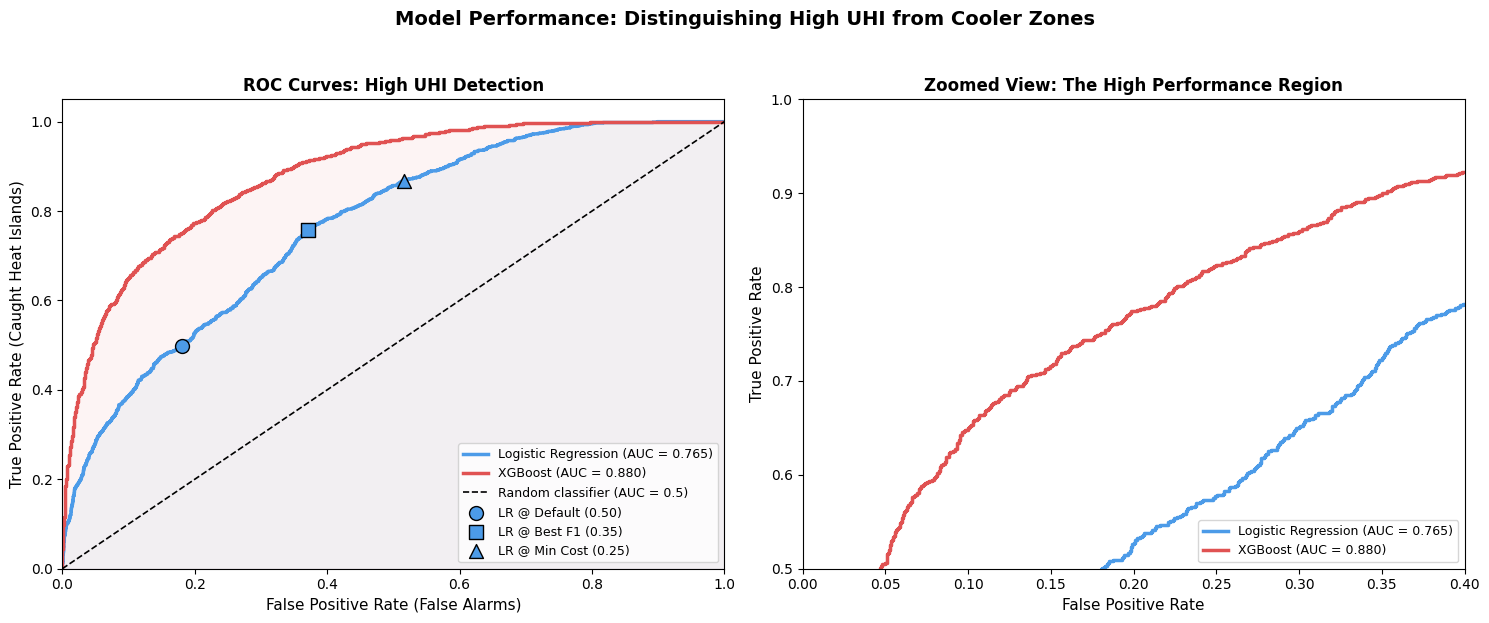

In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
import numpy as np

# =========================================================
# 1. Calculate Binary ROC Metrics for "High UHI"
# =========================================================
# (y_test_binary was created in the threshold tuning step)

# Logistic Regression ROC metrics
prob_high_lr = y_prob_lr_full[:, 2]
fpr_lr, tpr_lr, thresholds_lr = roc_curve(y_test_binary, prob_high_lr)
auc_lr = auc(fpr_lr, tpr_lr)

# XGBoost ROC metrics
prob_high_xgb = y_prob_xgb_full[:, 2]
fpr_xgb, tpr_xgb, thresholds_xgb = roc_curve(y_test_binary, prob_high_xgb)
auc_xgb = auc(fpr_xgb, tpr_xgb)


# =========================================================
# 2. Plotting the Curves
# =========================================================
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Model data mapping (Name, FPR, TPR, AUC, Thresholds, Color)
model_rocs = [
    ("Logistic Regression", fpr_lr,  tpr_lr,  auc_lr,  thresholds_lr,  "#4c9be8"), # Blue
    ("XGBoost",             fpr_xgb, tpr_xgb, auc_xgb, thresholds_xgb, "#e05252")  # Red
]

# ------------------- PLOT 1: Full ROC -------------------
ax = axes[0]

for name, fpr, tpr, roc_auc, _, color in model_rocs:
    ax.plot(fpr, tpr, lw=2.5, color=color, label=f"{name} (AUC = {roc_auc:.3f})")
    ax.fill_between(fpr, tpr, alpha=0.06, color=color)

ax.plot([0, 1], [0, 1], "k--", lw=1.2, label="Random classifier (AUC = 0.5)")

# Mark specific thresholds on the Logistic Regression curve
for t_mark, label, marker in [
    (0.50,             "Default (0.50)",           "o"),
    (best_f1_thresh,   f"Best F1 ({best_f1_thresh:.2f})",   "s"),
    (best_cost_thresh, f"Min Cost ({best_cost_thresh:.2f})","^"),
]:
    # Find the index of the threshold closest to our target mark
    idx = np.argmin(np.abs(thresholds_lr - t_mark))
    ax.scatter(fpr_lr[idx], tpr_lr[idx], s=100, zorder=5,
               color="#4c9be8", edgecolors="black", marker=marker,
               label=f"LR @ {label}")

ax.set_xlabel("False Positive Rate (False Alarms)", fontsize=11)
ax.set_ylabel("True Positive Rate (Caught Heat Islands)", fontsize=11)
ax.set_title("ROC Curves: High UHI Detection", fontsize=12, fontweight="bold")
ax.legend(fontsize=9, loc="lower right")
ax.set_xlim(0, 1); ax.set_ylim(0, 1.05)


# ------------------- PLOT 2: Zoomed ROC -------------------
ax = axes[1]
for name, fpr, tpr, roc_auc, _, color in model_rocs:
    ax.plot(fpr, tpr, lw=2.5, color=color, label=f"{name} (AUC = {roc_auc:.3f})")

ax.plot([0, 1], [0, 1], "k--", lw=1.2)
ax.set_xlim(0, 0.4); ax.set_ylim(0.5, 1.0) # Adjusted zoom window for better visibility
ax.set_xlabel("False Positive Rate", fontsize=11)
ax.set_ylabel("True Positive Rate", fontsize=11)
ax.set_title("Zoomed View: The High Performance Region", fontsize=12, fontweight="bold")
ax.legend(fontsize=9, loc="lower right")

plt.suptitle("Model Performance: Distinguishing High UHI from Cooler Zones",
             fontsize=14, fontweight="bold", y=1.03)
plt.tight_layout()
plt.show()

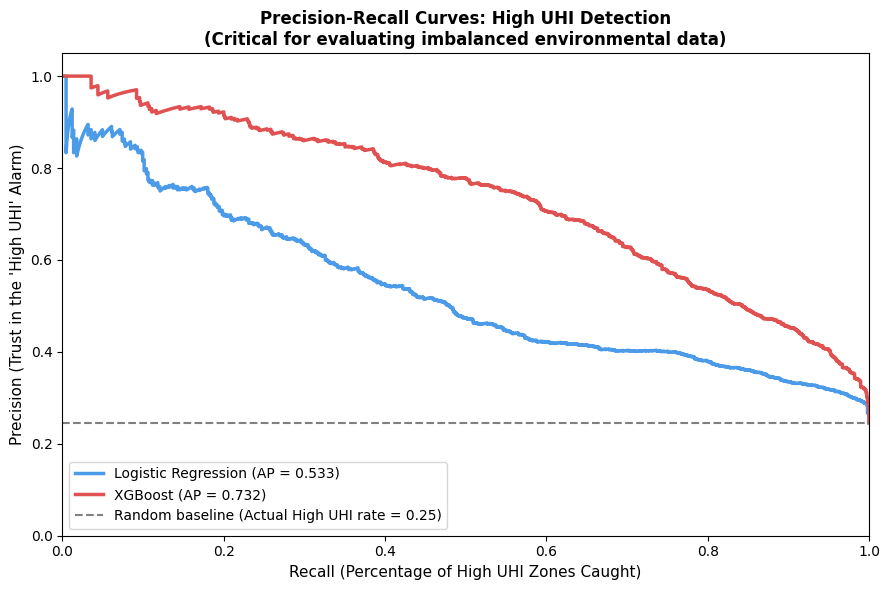

In [ ]:
from sklearn.metrics import precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(9, 6))

# 1. Loop through the models using the binarized "High UHI" probabilities
# We map LR to Blue and XGBoost to Red to maintain the previous theme
for name, y_prob, color in [
    ("Logistic Regression", prob_high_lr,  "#4c9be8"),
    ("XGBoost",             prob_high_xgb, "#e05252")
]:
    # Calculate PR curve metrics
    prec_c, rec_c, _ = precision_recall_curve(y_test_binary, y_prob)

    # Calculate Average Precision (AP) - the area under the PR curve
    ap = average_precision_score(y_test_binary, y_prob)

    # Plot the curve
    ax.plot(rec_c, prec_c, lw=2.5, color=color, label=f"{name} (AP = {ap:.3f})")

# 2. Add the baseline
# In a PR curve, the random baseline is simply the percentage of actual High UHI zones in your data.
baseline = y_test_binary.mean()
ax.axhline(baseline, color="gray", linestyle="--", lw=1.5,
           label=f"Random baseline (Actual High UHI rate = {baseline:.2f})")

# 3. Formatting
ax.set_xlabel("Recall (Percentage of High UHI Zones Caught)", fontsize=11)
ax.set_ylabel("Precision (Trust in the 'High UHI' Alarm)", fontsize=11)
ax.set_title("Precision-Recall Curves: High UHI Detection\n"
             "(Critical for evaluating imbalanced environmental data)",
             fontsize=12, fontweight="bold")

ax.legend(fontsize=10, loc="lower left")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1.05) # Give the top of the plot a little breathing room

plt.tight_layout()
plt.show()

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier

# 1. Explicitly define features and target from the matching Santiago dataframe
X_santiago = santiago_df.drop(columns=['Uhi_class_encoded'])
y_santiago = santiago_df['Uhi_class_encoded']

# 2. Shift the target down by 1 so XGBoost is happy (0, 1, 2)
y_cv = y_santiago - 1

# 3. Setup Cross-Validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# 4. Define Pipelines
pipe_lr = Pipeline([
    ("sc", StandardScaler()),
    ("lr", LogisticRegression(
        random_state=42,
        class_weight='balanced',
        solver='lbfgs',
        penalty="l2",
        C=0.1,
        max_iter=1000
    ))
])

pipe_xgb = Pipeline([
    ("sc", StandardScaler()),
    ("xgb", XGBClassifier(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=10,
        min_child_weight=20,
        random_state=42
    ))
])

# 5. Run Cross-Validation and Calculate Gap
cv_results = {}

# Define the metrics we want to track
scoring_metrics = {
    "auc": "roc_auc_ovr_weighted",
    "f1": "f1_weighted"
}

# Print table header
print(f"{'Model':<20} | {'Test AUC':<12} | {'Train F1':<10} | {'Test F1':<10} | {'F1 Gap':<10}")
print("-" * 75)

for name, pipe in [("Logistic Regression", pipe_lr), ("XGBoost", pipe_xgb)]:

    # Use cross_validate instead of cross_val_score to get training scores
    scores = cross_validate(
        pipe,
        X_santiago,
        y_cv,
        cv=cv,
        scoring=scoring_metrics,
        return_train_score=True # THIS is the magic parameter!
    )

    # Store the TEST scores exactly as before so your Boxplot code still works!
    cv_results[name] = {
        "AUC": scores['test_auc'],
        "F1": scores['test_f1']
    }

    # Calculate means across the 5 folds
    mean_test_auc = scores['test_auc'].mean()
    mean_train_f1 = scores['train_f1'].mean()
    mean_test_f1  = scores['test_f1'].mean()

    # Calculate the gap!
    gap_f1 = mean_train_f1 - mean_test_f1

    # Print the formatted row
    print(f"{name:<20} | {mean_test_auc:.4f}       | {mean_train_f1:.4f}     | {mean_test_f1:.4f}     | {gap_f1:.4f}")

Model                | Test AUC     | Train F1   | Test F1    | F1 Gap    
---------------------------------------------------------------------------
Logistic Regression  | 0.7106       | 0.5127     | 0.5110     | 0.0017
XGBoost              | 0.8383       | 0.8233     | 0.6978     | 0.1255


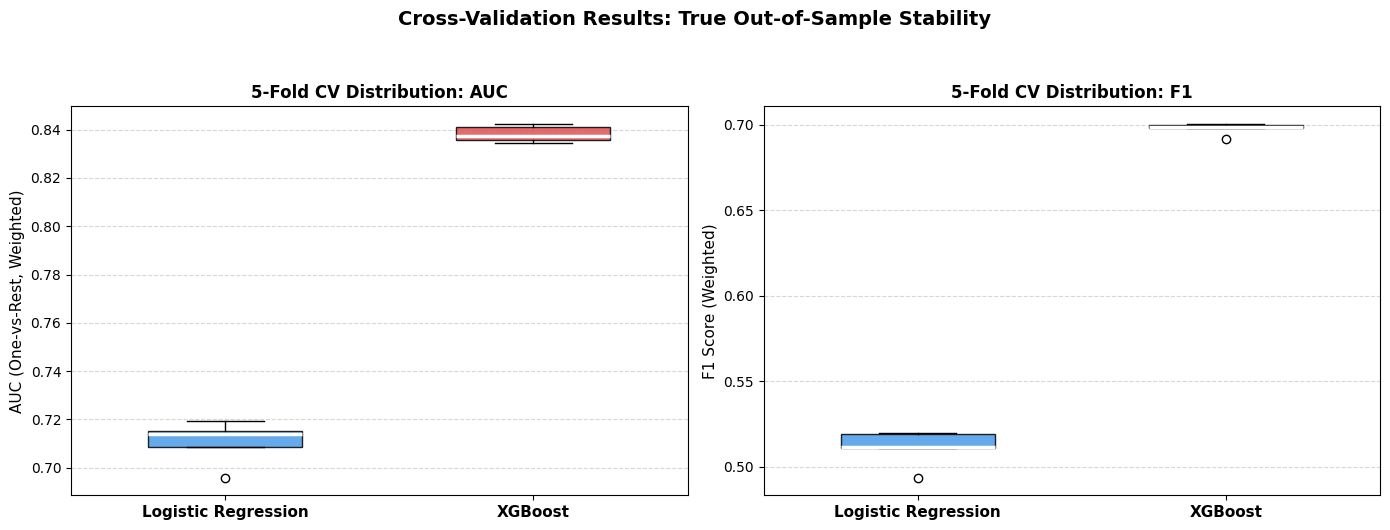

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Use our established UHI color theme: Blue for LR, Red for XGBoost
model_names = list(cv_results.keys())
box_colors  = ["#4c9be8", "#e05252"]

# Loop through our two recorded metrics
for ax, metric in zip(axes, ["AUC", "F1"]):

    # Extract the array of 5 scores for each model
    data = [cv_results[m][metric] for m in model_names]

    # Create the boxplot
    bp = ax.boxplot(data, patch_artist=True, widths=0.5,
                    medianprops=dict(color="white", lw=2.5))

    # Apply the colors
    for patch, color in zip(bp["boxes"], box_colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.85)

    # Formatting and labels
    ax.set_xticks(range(1, len(model_names) + 1))
    ax.set_xticklabels(model_names, fontsize=11, fontweight="bold")

    # Explicitly state that these are weighted multi-class metrics
    display_metric = "AUC (One-vs-Rest, Weighted)" if metric == "AUC" else "F1 Score (Weighted)"
    ax.set_ylabel(display_metric, fontsize=11)

    ax.set_title(f"5-Fold CV Distribution: {metric}", fontsize=12, fontweight="bold")

    # Add a subtle grid to make comparing heights easier
    ax.grid(axis='y', linestyle='--', alpha=0.5)

plt.suptitle("Cross-Validation Results: True Out-of-Sample Stability",
             fontsize=14, fontweight="bold", y=1.05)
plt.tight_layout()
plt.show()